[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ReevesJustin/data-driven-reloading/blob/main/notebooks/11_Peer_Review_Your_Own_Data.ipynb)

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/ReevesJustin/data-driven-reloading/main?filepath=notebooks/11_Peer_Review_Your_Own_Data.ipynb)

Time to complete: 10-15 minutes

# Peer Review Your Own Data — Self-Skepticism Checklist

**Goal:** Provide a self-skepticism checklist for reloading data analysis to avoid common pitfalls and ensure reliable conclusions.

## 1. The Checklist

Before declaring success in your reloading experiments, ask yourself these 10 questions. Each comes with a brief explanation and a key takeaway.

1. **Did I change only one variable at a time?**
   - Explanation: Testing multiple changes simultaneously makes it impossible to know which caused any observed effect.
   > **Takeaway:** Isolate variables to attribute results accurately.

2. **Is my sample size adequate for the effect I'm claiming?**
   - Explanation: Small samples can lead to false positives or negatives due to random variation.
   > **Takeaway:** Use statistical power calculations to ensure enough shots.

3. **Did I account for barrel temperature and other environmental factors?**
   - Explanation: Barrel heating can artificially inflate velocities over time, skewing results.
   > **Takeaway:** Control or measure environmental variables consistently.

4. **Am I cherry-picking my best group instead of averaging?**
   - Explanation: Selecting only the best data ignores natural variation and leads to over-optimism.
   > **Takeaway:** Analyze all data, not just the highlights.

5. **Would I bet $500 on this result repeating?**
   - Explanation: If you're not confident enough to risk money, the evidence isn't strong enough.
   > **Takeaway:** Treat skepticism as a bet on reality.

6. **Are there any obvious outliers or flyers in my data?**
   - Explanation: Extreme values can distort means and should be investigated or handled appropriately.
   > **Takeaway:** Inspect data for anomalies before trusting statistics.

7. **Did I test multiple groups per condition?**
   - Explanation: A single group per test can't distinguish signal from noise reliably.
   > **Takeaway:** Replicate conditions to confirm patterns.

8. **Is the difference I'm seeing larger than my measurement precision?**
   - Explanation: If changes are within error margins, they're likely noise, not signal.
   > **Takeaway:** Compare effects to your instrument's accuracy.

9. **Have I replicated this result at least once?**
   - Explanation: One-off results might be flukes; replication builds confidence.
   > **Takeaway:** Repeat experiments to verify findings.

10. **Am I letting the data speak or forcing it to say what I want?**
    - Explanation: Confirmation bias can make you ignore contradictory evidence.
    > **Takeaway:** Approach data with humility and openness.

## 2. Red Flags in Your Data

Visual examples of suspicious patterns using simulated data. These plots highlight common issues. (For GitHub viewing, static images would be embedded here if generated.)

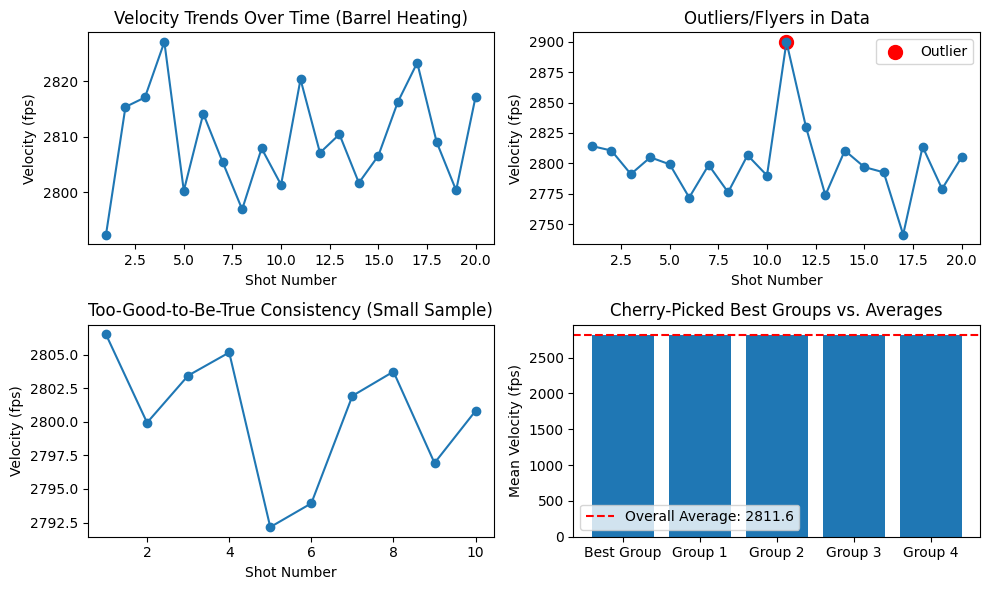

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated data for velocity trends over time (barrel heating)
shots = np.arange(1, 21)
velocities_heating = 2800 + 5 * np.log(shots) + np.random.normal(0, 10, 20)

plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.plot(shots, velocities_heating, marker='o')
plt.title('Velocity Trends Over Time (Barrel Heating)')
plt.xlabel('Shot Number')
plt.ylabel('Velocity (fps)')

# Outliers/flyers
velocities_normal = np.random.normal(2800, 20, 20)
velocities_outliers = velocities_normal.copy()
velocities_outliers[10] = 2900  # outlier

plt.subplot(2, 2, 2)
plt.plot(shots, velocities_outliers, marker='o')
plt.scatter(11, 2900, color='red', s=100, label='Outlier')
plt.title('Outliers/Flyers in Data')
plt.xlabel('Shot Number')
plt.ylabel('Velocity (fps)')
plt.legend()

# Too-good-to-be-true consistency in small samples
small_sample = np.random.normal(2800, 5, 10)  # unrealistically low SD

plt.subplot(2, 2, 3)
plt.plot(np.arange(1, 11), small_sample, marker='o')
plt.title('Too-Good-to-Be-True Consistency (Small Sample)')
plt.xlabel('Shot Number')
plt.ylabel('Velocity (fps)')

# Cherry-picked best groups vs. averages
groups = [np.random.normal(2800 + i*5, 20, 5) for i in range(5)]
best_group = max(groups, key=np.mean)
average = np.mean([np.mean(g) for g in groups])

plt.subplot(2, 2, 4)
plt.bar(['Best Group'] + [f'Group {i+1}' for i in range(4)], [np.mean(best_group)] + [np.mean(g) for g in groups[:4]])
plt.axhline(average, color='red', linestyle='--', label=f'Overall Average: {average:.1f}')
plt.title('Cherry-Picked Best Groups vs. Averages')
plt.ylabel('Mean Velocity (fps)')
plt.legend()

plt.tight_layout()
plt.show()

# For GitHub static fallback: plt.savefig('red_flags.png')  # Uncomment to save image

## 3. The Pre-Registration Mindset

Pre-registration means deciding your analysis plan BEFORE collecting data. This prevents p-hacking (trying many analyses until you find significance) and confirmation bias (seeing what you want to see).

Example: If testing powder charges, decide in advance: "I'll measure mean velocity and SD for 20 shots per charge, and compare using t-tests." Don't adjust based on results.

Another example: Avoid adding "outlier removal" post-hoc; define criteria beforehand.

> **Takeaway:** Plan your analysis before you pull the trigger.

## 4. Interactive Data Health Check Tool

Paste your velocities (comma-separated) below and run the cell to get a health check. (For GitHub, this is interactive in Jupyter; static version shows example output.)

In [2]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np

def calculate_stats(velocities):
    if not velocities:
        return "No data provided."
    try:
        data = np.array([float(v.strip()) for v in velocities.split(',')])
        mean = np.mean(data)
        sd = np.std(data, ddof=1)
        es = sd / mean * 100 if mean != 0 else 0  # Extreme Spread approximation
        range_val = np.ptp(data)
        
        # Outliers: using IQR
        q1 = np.percentile(data, 25)
        q3 = np.percentile(data, 75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = [v for v in data if v < lower_bound or v > upper_bound]
        
        warnings = []
        if len(data) < 20:
            warnings.append("Warning: Sample size < 20; results may be unreliable.")
        if sd < 10 and mean > 2000:  # rough flag for suspiciously low SD
            warnings.append("Warning: SD suspiciously low for mean velocity; check for data issues.")
        if outliers:
            warnings.append(f"Outliers detected: {outliers}")
        
        health_score = "Good" if not warnings else "Caution" if len(warnings) <= 2 else "Poor"
        
        result = f"""
        Basic Stats:
        - Mean: {mean:.2f} fps
        - SD: {sd:.2f} fps
        - ES: {es:.2f}%
        - Range: {range_val:.2f} fps
        
        Warnings:
        {"\n".join(warnings) if warnings else "None"}
        
        Overall Health: {health_score}
        """
        return result
    except ValueError:
        return "Invalid input. Please enter comma-separated numbers."

# Widget
text_area = widgets.Textarea(
    value='2800, 2810, 2795, 2820, 2805',
    placeholder='Paste velocities here, e.g., 2800, 2810, 2795',
    description='Velocities:',
    layout=widgets.Layout(width='50%', height='100px')
)

output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output(wait=True)
        result = calculate_stats(text_area.value)
        print(result)

button = widgets.Button(description="Check Health")
button.on_click(on_button_click)

display(text_area, button, output)

# Example output for GitHub: Run with default data to show static result.

Textarea(value='2800, 2810, 2795, 2820, 2805', description='Velocities:', layout=Layout(height='100px', width=…

Button(description='Check Health', style=ButtonStyle())

Output()

> **Key Takeaways**
> - Self-review process catches common analytical errors
> - Checklists ensure thorough data examination
> - Bias recognition improves result interpretation
> - Critical thinking about data prevents false conclusions
> - Systematic review methodology enhances reliability

[Previous: 10_When_Is_A_Result_Real.ipynb](10_When_Is_A_Result_Real.ipynb) | [Next: 12_What_About_The_Pros.ipynb](12_What_About_The_Pros.ipynb)